# Notebook 2: Create the labels

In [1]:
import sys
assert "olist_mlops" in sys.executable, f"wrong kernel selected in the editor - expected the olist_mlops env, got: {sys.executable}"

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## read the ml table from notebook 1

In [3]:
ARTIFACTS_DIR = Path("artifacts")

ml_table = pd.read_csv(ARTIFACTS_DIR / "01_ml_table.csv")

# dates come back as text after csv, parse them again
date_cols = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in date_cols:
    ml_table[col] = pd.to_datetime(ml_table[col])

ml_table.shape

(99441, 25)

## build the label

In [4]:
# we can only label an order if it actually has a delivered date and an estimated date
no_label = ml_table[
    ml_table["order_delivered_customer_date"].isna()
    | ml_table["order_estimated_delivery_date"].isna()
]
print("orders with no usable label:", len(no_label))
no_label["order_status"].value_counts()

orders with no usable label: 2965


order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

In [5]:
ml_table = ml_table[
    ml_table["order_delivered_customer_date"].notna()
    & ml_table["order_estimated_delivery_date"].notna()
].copy()

ml_table.shape

(96476, 25)

In [6]:
ml_table["late"] = (ml_table["order_delivered_customer_date"] > ml_table["order_estimated_delivery_date"]).astype(int)

ml_table["late"].value_counts()

late
0    88649
1     7827
Name: count, dtype: int64

## check the label on a few real orders before trusting it

In [7]:
cols = ["order_id", "order_estimated_delivery_date", "order_delivered_customer_date", "late"]

print("late orders:")
print(ml_table[ml_table["late"] == 1][cols].head())

print("\non time orders:")
print(ml_table[ml_table["late"] == 0][cols].head())

late orders:
                            order_id order_estimated_delivery_date  \
20  203096f03d82e0dffbc41ebc2e2bcfb7                    2017-09-28   
25  fbf9ac61453ac646ce8ad9783d7d0af6                    2018-03-12   
35  8563039e855156e48fccee4d611a3196                    2018-03-20   
41  6ea2f835b4556291ffdc53fa0b3b95e8                    2017-12-21   
57  66e4624ae69e7dc89bd50222b59f581f                    2018-04-02   

   order_delivered_customer_date  late  
20           2017-10-09 22:23:46     1  
25           2018-03-21 22:03:54     1  
35           2018-03-20 00:59:25     1  
41           2017-12-28 18:59:23     1  
57           2018-04-03 13:28:46     1  

on time orders:
                           order_id order_estimated_delivery_date  \
0  e481f51cbdc54678b7cc49136f2d6af7                    2017-10-18   
1  53cdb2fc8bc7dce0b6741e2150273451                    2018-08-13   
2  47770eb9100c2d0c44946d9cf07ec65d                    2018-09-04   
3  949d5b44dbf5de918fe9c16f

## class distribution

late
0    88649
1     7827
Name: count, dtype: int64
late
0    91.89
1     8.11
Name: proportion, dtype: float64


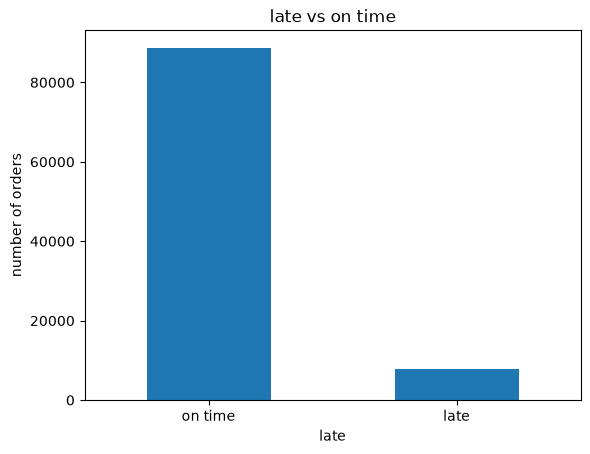

In [8]:
counts = ml_table["late"].value_counts()
pct = (ml_table["late"].value_counts(normalize=True) * 100).round(2)

print(counts)
print(pct)

counts.plot(kind="bar")
plt.xticks([0, 1], ["on time", "late"], rotation=0)
plt.ylabel("number of orders")
plt.title("late vs on time")
plt.show()

clear imbalance here, on time is the big majority and late is the minority class.
accuracy alone would look good just by always predicting on time, so later we need class_weight
and a metric like recall/precision or PR-AUC for the late class, not just accuracy.

i used `order_delivered_customer_date` and `order_delivered_carrier_date` for build the label only

## save the artifact

In [9]:
out_path = ARTIFACTS_DIR / "02_labeled_table.csv"
ml_table.to_csv(out_path, index=False)
print("saved:", out_path, "shape:", ml_table.shape)

saved: artifacts\02_labeled_table.csv shape: (96476, 26)
